In [1]:
from mnesis_boilerplate import torch, np, data_cache, Path, RECOMPUTE, DEBUG, get_scores, printfig, approx_equals, SubplotParams, pprint, splt, i_pattern, phi, figpath, Params, asdict, loss_fn, pd, plt, sns
from mnesis_chains import SpikingPattern, HD_SNN
# RECOMPUTE = True
# 
exp = 'text'


datetag = '2026-08-06'
CUDA: True, Device: NVIDIA RTX A2000 12GB
Using device: cuda


In [2]:
opt_dict = dict(N_neuron=1024, N_time=2000//DEBUG+41, 
                N_pattern=4, # HACK to make it easier to learn the Lorenz attractor with only 4 patterns
                lif_beta=0.4,
                lif_threshold=.74, do_pinv=True)
opt = Params(**opt_dict)
opt

Params(datetag='2026-08-06', N_neuron=1024, num_delay=41, N_pattern=4, N_time=2041, N_pretime=50, p_A=0.00016, p_flip=0.01, seed=2018, lif_beta=0.4, lif_threshold=0.74, learn_beta=False, learn_threshold=False, do_pinv=True, do_deconv=True, num_epochs=256, num_warmup_epochs=16, base_lr=0.03, final_lr=0.001, delta1=0.01, delta2=1e-05, dropout=0.25, alpha_surrogate=5.0, surrogate_name='FastSigmoid', loss_name='SpikeF1scoreLoss', reset_mechanism='subtract', optimizer='sgd', verbose=False, fig_width=30, fig_height=15, phi=1.61803, N_time_show=512, N_neuron_show=200, N_scan=36)

# working memory with text



### getting text: Wikipedia

In [3]:
%pip install -q -U datasets  

Note: you may need to restart the kernel to use updated packages.


In [4]:
from datasets import load_dataset
# Load a smaller, pre-processed Wikipedia dataset
dataset = load_dataset("wikimedia/wikipedia", "20231101.fr")["train"]
print(dataset[0]["text"][:500])

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/17 [00:00<?, ?it/s]

Antoine Meillet, né le  à Moulins (Allier) et mort le  à Châteaumeillant (Cher), est un philologue français, le principal linguiste français des premières décennies du .

Biographie

Enfance et formation 
Paul Jules Antoine Meillet est d'origine bourbonnaise, fils d'un notaire de Châteaumeillant (Cher). Il naît à Moulins le 11 novembre 1866.

Il passe son enfance à Châteaumeillant, puis fait ses études secondaires au lycée de Moulins.

Étudiant à partir de 1885 à la faculté des lettres de Paris 


In [5]:
dataset['title']

Column(['Antoine Meillet', 'Algèbre linéaire', 'Algèbre générale', 'Algorithmique', 'Politique en Argentine', ...])

In [6]:
len(dataset)

2564646

In [7]:
# titles_with_neur = [article["title"] for article in dataset if "Neur" in article["title"]]
# titles_with_neur

for article in dataset:
    if article["title"] == "Neurosciences computationnelles":
        NeuroComp_text = article["text"]
        break
NeuroComp_text

"Les neurosciences computationnelles (NSC) sont un champ de recherche des neurosciences qui s'applique à découvrir les principes computationnels des fonctions cérébrales et de l'activité neuronale, c'est-à-dire des algorithmes génériques qui permettent de comprendre l'implémentation dans notre système nerveux central du traitement de l'information associé à nos fonctions cognitives. Ce but a été défini en premier lieu par David Marr dans une série d'articles fondateurs.\n \nOn essaie de comprendre le traitement de l'information opéré par le cerveau à l'aide des modèles des sciences informatiques combinés à l'expérimentation et aux simulations numériques.\n\nHistoriquement, un des premiers modèles introduits en neurosciences computationnelles est le modèle « intègre et tire » par Louis Lapicque en 1907. Cet article très influent en neurosciences théoriques et computationnelles introduit un des modèles les plus populaires encore à l'heure actuelle. Cet article a été traduit en anglais à 

In [8]:
print(dataset[0]["text"][:500])

Antoine Meillet, né le  à Moulins (Allier) et mort le  à Châteaumeillant (Cher), est un philologue français, le principal linguiste français des premières décennies du .

Biographie

Enfance et formation 
Paul Jules Antoine Meillet est d'origine bourbonnaise, fils d'un notaire de Châteaumeillant (Cher). Il naît à Moulins le 11 novembre 1866.

Il passe son enfance à Châteaumeillant, puis fait ses études secondaires au lycée de Moulins.

Étudiant à partir de 1885 à la faculté des lettres de Paris 


### tokenization

In [9]:
%pip install -q tiktoken

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import tiktoken

enc = tiktoken.get_encoding("cl100k_base")   # tokenizer used by gpt‑3.5‑turbo / gpt‑4

text = "Le rapide renard brun saute par-dessus 2 chiens paresseux."
tokens = enc.encode(text)
print("Token IDs :", tokens)
print("Decoded   :", enc.decode(tokens))
print("Token count:", len(tokens))

Token IDs : [791, 4062, 14198, 39935, 35308, 927, 220, 17, 16053, 12875, 13]
Decoded   : The quick brown fox jumps over 2 lazy dogs.
Token count: 11


In [11]:
for enc_name in tiktoken.list_encoding_names():
    vocab_size = tiktoken.get_encoding(enc_name).max_token_value + 1            # token IDs go from 0 to max_token_value
    print(f'for {enc_name=}, {vocab_size=}')   # → 100256 (≈ 100 k)

for enc_name='gpt2', vocab_size=50257
for enc_name='r50k_base', vocab_size=50257
for enc_name='p50k_base', vocab_size=50281
for enc_name='p50k_edit', vocab_size=50284
for enc_name='cl100k_base', vocab_size=100277
for enc_name='o200k_base', vocab_size=200019
for enc_name='o200k_harmony', vocab_size=201088


### spike encoding

In [12]:
filename = data_cache / f"{exp}_wikipedia_fr_token_ids.npy"

if filename.exists() and not RECOMPUTE:
    token_ids = np.load(filename)
else:
    # Extract all articles
    articles = [article["text"] for article in dataset]

    # Shuffle articles randomly
    np.random.shuffle(articles)

    # Concatenate all articles into a single text
    concatenated_text = " ".join(articles)

    # encoide the first n_char characters of the concatenated text into token IDs
    n_char = 100_000_000
    token_ids = enc.encode(concatenated_text[:n_char])
    np.save(filename, np.array(token_ids, dtype=np.uint32))

In [13]:
token_ids[:100]

array([ 2356,  9424,    69, 65220,  1826,   653, 13259, 57123,   409,
       14539,    68,  8288,  1791,   648,   382,  5116,  4815,    50,
       33462,   978,  7010,   514,  9474,   409,  9424,    69, 65220,
          11,  3900,   513,   503,  6672,  7010,  1208, 13081,   648,
         409,  9424,    69, 65220,    11,  3869,  9424,    69, 65220,
          11,   665,  4809,   951, 80013, 38672,  9620,    13,  4815,
       56948,  3857,   409,  1208, 44229, 20712,  8065, 89429,   355,
         409,  1208, 39973,   409,  9424,    69, 65220,    11,   264,
       24560,   649, 35965,  8047,  1880,  9517,  6750,  8047,   665,
         220,  4468,    17,  1880,   665,   220,  2550,    19,    13,
        2009, 13259, 57123,   264,  5019,  3611, 10036,   812,  3625,
         436], dtype=uint32)

In [14]:
np.unique(token_ids).shape

(51935,)

In [15]:
# Compute unique token IDs and their counts
unique_ids, counts = np.unique(token_ids, return_counts=True)

# Sort by frequency (descending order)
sorted_indices = np.argsort(-counts)
sorted_ids = unique_ids[sorted_indices]
sorted_counts = counts[sorted_indices]

# Compute probabilities
total = np.sum(counts)
probs = sorted_counts / total

# Print the top 50 most common tokens
for i in range(min(50, len(sorted_ids))):
    token_id = sorted_ids[i]
    count = sorted_counts[i]
    prob = probs[i]
    token = enc.decode([token_id])

    # Escape special characters
    escaped_token = token.replace("\n", "\\n").replace("\t", "\\t").replace("\r", "\\r")

    print(f"ID {token_id:5d} \t| count {count:7d} \t| probability {prob:.6f} \t| token '{escaped_token}'")

ID   409 	| count  951623 	| probability 0.032165 	| token ' de'
ID    11 	| count  873178 	| probability 0.029514 	| token ','
ID   220 	| count  641747 	| probability 0.021691 	| token ' '
ID  1208 	| count  447042 	| probability 0.015110 	| token ' la'
ID  1880 	| count  371942 	| probability 0.012572 	| token ' et'
ID    13 	| count  332614 	| probability 0.011243 	| token '.'
ID   514 	| count  304655 	| probability 0.010298 	| token ' le'
ID   978 	| count  303722 	| probability 0.010266 	| token 'é'
ID     6 	| count  296648 	| probability 0.010027 	| token '''
ID  3869 	| count  293299 	| probability 0.009914 	| token ' à'
ID   326 	| count  292620 	| probability 0.009891 	| token ' l'
ID   665 	| count  275026 	| probability 0.009296 	| token ' en'
ID   198 	| count  250786 	| probability 0.008477 	| token '\n'
ID   294 	| count  240228 	| probability 0.008120 	| token ' d'
ID  3930 	| count  233495 	| probability 0.007892 	| token ' du'
ID   951 	| count  226019 	| probabilit

Text(0.5, 1.0, "Zipf's Law: Token Frequency Distribution")

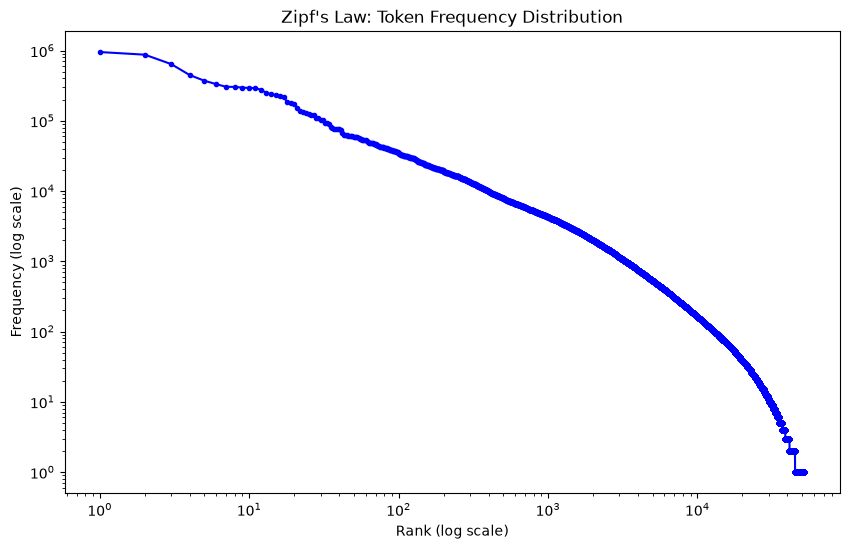

In [16]:
# Compute ranks (1-based)
ranks = np.arange(1, len(sorted_counts) + 1)

# Log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(ranks, sorted_counts, marker=".", linestyle="-", color="blue")
plt.xlabel("Rank (log scale)")
plt.ylabel("Frequency (log scale)")
plt.title("Zipf's Law: Token Frequency Distribution")


In [17]:
# Find hapax legomena (tokens with count == 1)
hapax_ids = unique_ids[counts == 1]

for token_id in hapax_ids[:10]:
    token = enc.decode([token_id])
    escaped_token = token.replace("\n", "\\n").replace("\t", "\\t").replace("\r", "\\r")
    print(f"Hapax legomenon: '{escaped_token}' (ID: {token_id})")

Hapax legomenon: '----' (ID: 381)
Hapax legomenon: '('' (ID: 493)
Hapax legomenon: '__' (ID: 565)
Hapax legomenon: ' */' (ID: 642)
Hapax legomenon: 'bject' (ID: 807)
Hapax legomenon: 'essage' (ID: 808)
Hapax legomenon: '.set' (ID: 995)
Hapax legomenon: 'indow' (ID: 1000)
Hapax legomenon: ' &&' (ID: 1024)
Hapax legomenon: '/*' (ID: 1075)


## convert as spikes

In [18]:
for article in dataset:
    if article["title"] == "Neurosciences":
        test_text = article["text"]
        break
test_text

test_tokens = enc.encode(test_text)
len(test_tokens), test_text[:1000]


(4570,
 "Les neurosciences sont les études scientifiques du système nerveux, tant du point de vue de sa structure que de son fonctionnement, depuis l'échelle moléculaire jusqu'au niveau des organes, comme le cerveau, voire de l'organisme tout entier.\n\nLe champ de la recherche en neurosciences est un champ transdisciplinaire : la biologie, la chimie, les mathématiques, la bio-informatique ainsi que la neuropsychologie sont utilisées en neurosciences. L'arsenal conceptuel et méthodologique des neurosciences va de pair avec une diversité d'approches dans l'étude des aspects moléculaires, cellulaires, développementaux, neuroanatomiques, neurophysiologiques, cognitifs, génétiques, évolutionnaires, computationnels ou neurologiques du système nerveux.\n\nLes neurosciences sont souvent présentées sous l'angle des neurosciences cognitives, tout particulièrement les travaux utilisant l'imagerie cérébrale : certaines applications des neurosciences cognitives peuvent être employées en économie, 

In [19]:
import torch

def corpus_to_binary(token_ids, N_neuron):
    """
    Convert a corpus of token IDs to a binary tensor of shape (N_neuron, N_token).

    Args:
        token_ids: 1D LongTensor of shape (N_token,) containing token IDs
        N_neuron: int, size of the binary vector

    Returns:
        FloatTensor of shape (N_neuron, N_token) with values 0.0 or 1.0
    """
    unique_ids = torch.unique(token_ids)
    num_tokens = len(unique_ids)

    max_tokens = 1 + N_neuron + N_neuron * (N_neuron - 1) // 2
    if num_tokens > max_tokens:
        raise ValueError(f"Too many unique tokens ({num_tokens}) for N_neuron={N_neuron}. Max: {max_tokens}")

    sorted_ids = torch.sort(unique_ids).values
    ranks = torch.searchsorted(sorted_ids, token_ids)

    device = token_ids.device
    output = torch.zeros((N_neuron, token_ids.shape[0]),
                         dtype=torch.float32, device=device)

    mask_w1 = (ranks > 0) & (ranks <= N_neuron)
    if mask_w1.any():
        bit_indices = (ranks[mask_w1] - 1).long()
        token_indices = torch.where(mask_w1)[0]
        output[bit_indices, token_indices] = 1.0

    mask_w2 = ranks > N_neuron
    if mask_w2.any():
        local_rank = (ranks[mask_w2] - N_neuron - 1).long()
        discriminant = (2 * N_neuron - 1) ** 2 - 8 * local_rank.float()
        discriminant = torch.clamp(discriminant, min=0)
        sqrt_disc = torch.sqrt(discriminant)
        i = torch.floor((2 * N_neuron - 1 - sqrt_disc) / 2).long()
        j = local_rank - (i * N_neuron - i * (i + 1) // 2) + i + 1
        token_indices = torch.where(mask_w2)[0]
        output[i, token_indices] = 1.0
        output[j, token_indices] = 1.0

    return output


In [ ]:
filename = data_cache / f"{exp}_wikipedia_fr_corpus_as_spike.pt"
if filename.exists() and not RECOMPUTE:
    from mnesis_boilerplate import load_binary_tensor
    corpus_as_spike = load_binary_tensor(filename)
else:
    from mnesis_boilerplate import save_binary_tensor
    # HACK to be able to store the whole corpus as a spike tensor, we only take the first 5 million tokens
    corpus_as_spike = corpus_to_binary(torch.Tensor(token_ids[:5_000_000]).long(), N_neuron=opt.N_neuron)
    save_binary_tensor(corpus_as_spike, filename)

In [22]:
# corpus_as_spike.shape

In [23]:
# corpus_as_spike[:10, :20]

## define the pattern generator

In [24]:
pprint('DEFINING THE PATTERN GENERATOR: Creating a spike pattern generator for text data')

DEFINING THE PATTERN GENERATOR: Creating a spike pattern generator for text data


In [25]:
seed = None
rng = np.random.default_rng(seed)
x= rng.choice(30, size=25, replace=False)
x.sort()
x

array([ 0,  1,  2,  4,  5,  6,  7,  9, 10, 11, 12, 15, 16, 17, 18, 19, 20,
       21, 22, 23, 24, 26, 27, 28, 29])

In [26]:
class TextSpikingPattern(SpikingPattern):
    def __init__(self, token_ids, corpus_as_spike):
        super().__init__()
        self.desc = "A text spike pattern generator"
        self.token_ids = token_ids # the full corpus as a list of token IDs
        self.corpus_as_spike = corpus_as_spike
        # self.n_token = len(self.token_ids)
        self.n_token = self.corpus_as_spike.shape[1]

    # def init(self, opt, token_ids, corpus_as_spike):
    #     self.opt = opt

    def __call__(self, seed=None, verbose=False):
        """
        Generate N_pattern realizations of length N_time from the spiking pattern of the whole corpus.

        """

        num_possible = self.n_token - self.opt.N_time  + 1

        if seed is None:
            if verbose: print("Using default seed from options")
            seed = self.opt.seed
        rng = np.random.default_rng(seed)
        pattern_idxs_np = rng.choice(num_possible, size=self.opt.N_pattern, replace=False)
        pattern_idxs = torch.from_numpy(pattern_idxs_np)
        offsets = torch.arange(self.opt.N_time).unsqueeze(0)
        col_indices = pattern_idxs.unsqueeze(1) + offsets
        spikes = self.corpus_as_spike[:, col_indices].permute(1, 0, 2).float().to(self.opt.device)

        return spikes

tsp = TextSpikingPattern(token_ids, corpus_as_spike)
tsp.init(opt)
spike_pattern = tsp()

## Learn the target

In [27]:
pprint('LEARNING THE TARGET: Training the spiking neural network to learn the Lorenz attractor')

LEARNING THE TARGET: Training the spiking neural network to learn the Lorenz attractor


In [28]:
hd = HD_SNN(opt, TextSpikingPattern(token_ids, corpus_as_spike))
hd.target().shape, opt.N_neuron, opt.N_time

(torch.Size([4, 1024, 2041]), 1024, 2041)

In [29]:
opt

Params(datetag='2026-08-06', N_neuron=1024, num_delay=41, N_pattern=4, N_time=2041, N_pretime=50, p_A=0.00016, p_flip=0.01, seed=2018, lif_beta=0.4, lif_threshold=0.74, learn_beta=False, learn_threshold=False, do_pinv=True, do_deconv=True, num_epochs=256, num_warmup_epochs=16, base_lr=0.03, final_lr=0.001, delta1=0.01, delta2=1e-05, dropout=0.25, alpha_surrogate=5.0, surrogate_name='FastSigmoid', loss_name='SpikeF1scoreLoss', reset_mechanism='subtract', optimizer='sgd', verbose=False, fig_width=30, fig_height=15, phi=1.61803, N_time_show=512, N_neuron_show=200, N_scan=36)

In [30]:
model_filename = data_cache / f"{hd.opt.datetag}_{exp}_weights.pth"
lock_filename = model_filename.with_suffix('.lock')
if RECOMPUTE:
    model_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
    lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
try:
    model_state_dict = torch.load(model_filename, map_location=torch.device(hd.opt.device))
    hd.net.load_state_dict(model_state_dict)
    hd.net.eval()
    lock_filename.unlink(missing_ok=True) # in case the lock file was not unlinked
    print(f"Model weights loaded from {model_filename}") # Add a log message
except FileNotFoundError:
    if not lock_filename.exists():
        print(f"Model file not found: {model_filename}, intitializing the new model.")
        lock_filename.touch(exist_ok=True)
        ##################
        hd.update_weight()
        hd.learn_model()
        ##################
        torch.save(hd.net.state_dict(), model_filename)
        lock_filename.unlink(missing_ok=True)
    else:
        print(f"Model file is locked: {lock_filename}, passing.")

Model weights loaded from ../cached_data/2026-08-06_text_weights.pth


In [31]:
# # TODO reconstruct text from the spikes and compare with the original text. This will require a mapping from neuron addresses back to token IDs and then decoding those token IDs back to text using the tokenizer.

# for article in dataset:
#     if article["title"] == "Neurosciences computationnelles":
#         text = article["text"]
#         break
# text_token_ids = enc.encode(text)

In [32]:
with torch.no_grad():
    target = hd.target()
    target_full = torch.nn.functional.pad(target, (opt.N_pretime, opt.N_pretime))
    input_spikes = hd.get_input_spikes()
    _, _, spikes = hd.forward_pass(input_spikes)
    spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    target_evoked = target[:, :, hd.opt.num_delay:]

    precision, recall, f1_score = get_scores(spikes_evoked, target_evoked)
    print(f'precision = {precision:.3f}\t recall = {recall:.3f}\t f1_score = {f1_score:.3f} ')

precision = 1.000	 recall = 0.972	 f1_score = 0.986 


(torch.Size([4, 1024, 2141]), 3074.0, 3236.0)

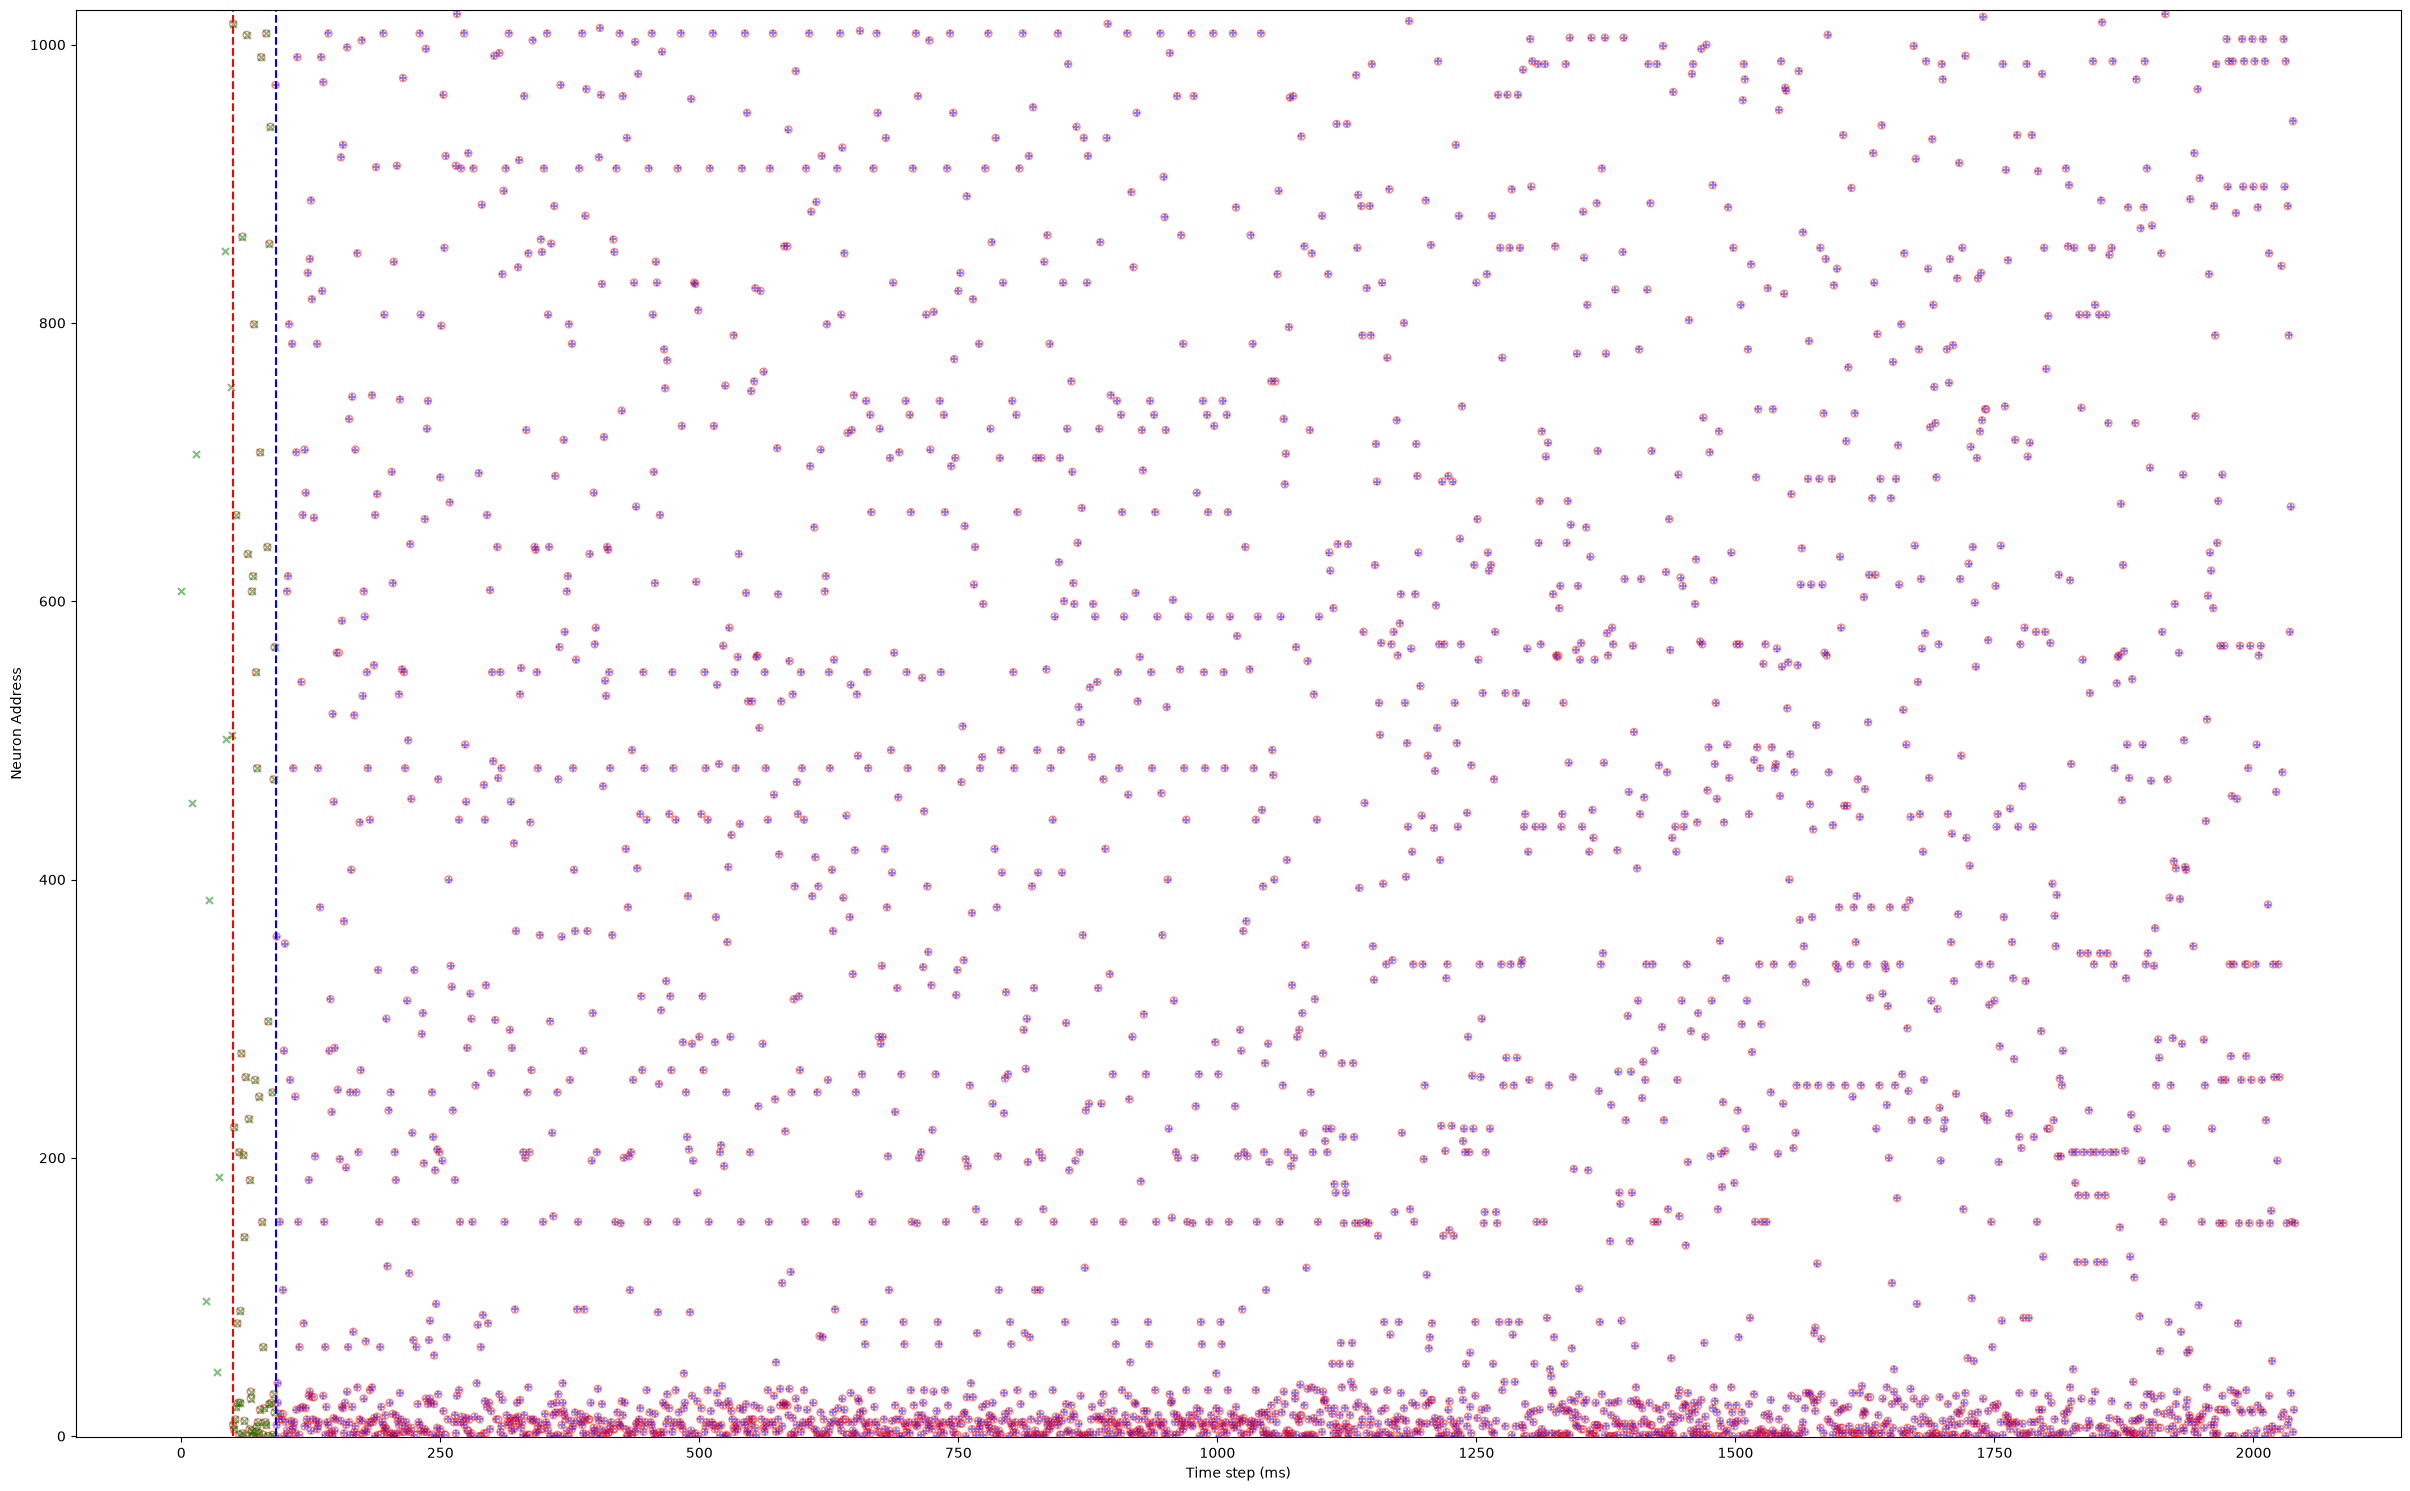

In [33]:
fig, ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
opt.N_neuron_show = opt.N_neuron
opt.N_time_show = opt.N_time
splt.raster(spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="blue", marker='+', alpha=.5)
splt.raster(target_full[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
splt.raster(input_spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="green", marker='x', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
spikes.shape, spikes[i_pattern, :, :].sum().item(), target[i_pattern, :, :].sum().item()

## optimizing learning parameters with optuna

In [34]:
pprint('OPTIMIZING LEARNING PARAMETERS WITH OPTUNA: Hyperparameter optimization using Bayesian search')


OPTIMIZING LEARNING PARAMETERS WITH OPTUNA: Hyperparameter optimization using Bayesian search


In [42]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import warnings
warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning,)
optuna_filename = data_cache / f"{opt.datetag}_{exp}_optuna.sqlite3"
lock_filename, study = optuna_filename.with_suffix('.lock'), 1
if RECOMPUTE:
    optuna_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
    lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
%ls -l {optuna_filename}

ls: impossible d'accéder à '../cached_data/2026-08-06_text_optuna.sqlite3': Aucun fichier ou dossier de ce nom


In [ ]:
def objective(trial):    
    new_opt = Params(**opt_dict)

    new_opt.do_deconv = trial.suggest_categorical('do_deconv', [True, False])
    new_opt.do_pinv = trial.suggest_categorical('do_pinv', [True, False])
    new_opt.learn_beta = trial.suggest_categorical('learn_beta', [True, False])
    new_opt.learn_threshold = trial.suggest_categorical('learn_threshold', [True, False])
    new_opt.reset_mechanism = trial.suggest_categorical('reset_mechanism', ['zero', 'subtract'])
    new_opt.optimizer = trial.suggest_categorical('optimizer', ['adamw', 'rmsprop', 'adadelta', 'sgd', 'adam']) # 'adagrad', 'sparseadam', 

    # new_opt.surrogate_name = trial.suggest_categorical('surrogate_name', ['FastSigmoid', 'LeakySpikeOperator', 'ATan', 'Sigmoid', 'SpikeRateEscape'])
    # new_opt.loss_name = trial.suggest_categorical('loss_name', [  'SpikeF1scoreLoss', 'MSELoss', 'L1Loss'])

    new_opt.lif_beta = trial.suggest_float('lif_beta', 0, 1)
    scale = 10
    scale = 3.618    
    new_opt.alpha_surrogate = trial.suggest_float('alpha_surrogate', new_opt.alpha_surrogate / scale, new_opt.alpha_surrogate * scale, log=True)
    new_opt.base_lr = trial.suggest_float('base_lr', new_opt.base_lr / scale, new_opt.base_lr * scale, log=True)
    new_opt.final_lr = trial.suggest_float('final_lr', new_opt.final_lr / scale, new_opt.final_lr * scale, log=True)
    new_opt.delta1 = trial.suggest_float('delta1', new_opt.delta1 / scale, min((new_opt.delta1 * scale, .99)), log=True)
    new_opt.delta2 = trial.suggest_float('delta2', new_opt.delta2 / scale, min((new_opt.delta2 * scale, .99)), log=True)
    new_opt.dropout = trial.suggest_float('dropout', 0, 1)
    new_opt.lif_threshold = trial.suggest_float('lif_threshold', new_opt.lif_threshold / scale, new_opt.lif_threshold * scale, log=True)

    try:
        hd = HD_SNN(new_opt, TextSpikingPattern(token_ids, corpus_as_spike))
        hd.update_weight()
        hd.learn_model(verbose=False)
        
        with torch.no_grad():
            # draw causes (SMs) - hidden to the observer
            input_spikes = hd.get_input_spikes()
            _, _, spikes = hd.forward_pass(input_spikes)
            spikes_ = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
            target_ = hd.target()
            target_ = target_[:, :, hd.opt.num_delay:]
            loss_val = loss_fn(spikes_, target_)

        return loss_val.item()
    except Exception as e:
        print(f"Error occurred: {e}")
        return 1.
        
N_optuna_scan = 100
N_optuna_scan = 200
# N_optuna_scan = 1000
N_optuna_scan = 200 // DEBUG**2

if not lock_filename.exists():
    # 3. Create a study object and optimize the objective function.
    study = optuna.create_study(
        storage=f"sqlite:///{str(optuna_filename)}",
        sampler=optuna.samplers.TPESampler(multivariate=True, warn_independent_sampling=False),
        direction="minimize",
        load_if_exists=True,
        study_name=opt.datetag,
    )

    if len(study.trials) < N_optuna_scan:
        print(f"Optuna file not found or unlocked: {optuna_filename}, starting optimization.")
        lock_filename.touch(exist_ok=True)

        if len(study.trials)>0:
            print("So far, Best params: ", study.best_params, end=', ')
            print("Best value: ", study.best_value)

        print(
            f"Starting optimization on {max(N_optuna_scan - len(study.trials), 0)} trials with {len(study.trials)} existing trials."
        )
        study.optimize(objective, n_trials=max((N_optuna_scan - len(study.trials), 0)), n_jobs=1, show_progress_bar=True)
        lock_filename.unlink(missing_ok=True)
else:
    print(f"Optuna file is locked: {lock_filename}, passing.")
    study = None

Optuna file not found or unlocked: ../cached_data/2026-08-06_text_optuna.sqlite3, starting optimization.
Starting optimization on 200 trials with 0 existing trials.


/tmp/ipykernel_1706683/266208113.py:53: FutureWarning: `warn_independent_sampling` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  sampler=optuna.samplers.TPESampler(multivariate=True, warn_independent_sampling=False),


  0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
if not study is None:
    study = optuna.load_study(storage=f"sqlite:///{str(optuna_filename)}", study_name=opt.datetag)
else:
    print("Study is None (likely due to lock), skipping load.")

In [ ]:
if not study is None:
    print(f'number of trials in study: {len(study.trials)}')
else:
    print("Study is None, skipping trials display.")

number of trials in study: 200


In [ ]:
if not study is None:
    print(50 * "-.")
    print("Best params: ", study.best_params)
    print("Best value: ", study.best_value)
    # print("Best Trial params: ", study.best_trial.params)
else:
    print("Study is None, skipping best-trial summary.")

-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.
Best params:  {'do_deconv': False, 'do_pinv': False, 'learn_beta': True, 'learn_threshold': False, 'reset_mechanism': 'subtract', 'optimizer': 'adam', 'lif_beta': 0.39206113557391153, 'alpha_surrogate': 1.7605073782923895, 'base_lr': 0.0136448398113211, 'final_lr': 0.0005033601146921496, 'delta1': 0.0035130267525126965, 'delta2': 1.4380039360967933e-05, 'dropout': 0.6636995773223274, 'lif_threshold': 1.5196319894139783}
Best value:  1.0


In [ ]:
if not study is None: 
    import numpy as np
    print("=" * 60)
    print("OPTUNA STUDY ANALYSIS")
    print("=" * 60)

    # 1. Parameter Importances (Ranking of Most Important Parameters)
    print("\n[1] PARAMETER IMPORTANCE RANKING:")
    try:
        importance_dict = optuna.importance.get_param_importances(study)
        for param, imp in sorted(importance_dict.items(), key=lambda item: item[1], reverse=True):
            print(f"{param:<30}: {imp:.3f}")
    except Exception as e:
        print("Error computing importance:", str(e))

    # 2. Best Value and Confidence Intervals for Each Parameter
    print("\n[2] BEST VALUES WITH CONFIDENCE INTERVALS:")

    if not study.trials:
        print("No trials found.")
    else:
        best_trial = study.best_trial
        print(f"\nBest Objective Value: {best_trial.value:.5f}")

        # Collect all valid trials
        completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

        if not completed_trials:
            print("No completed trials available.")
        else:
            # Get top 10% performing trials for confidence interval estimation
            top_trials = sorted(completed_trials, key=lambda t: t.value, reverse=True)[:max(1, len(completed_trials) // 10)]

            params_all = {pname: [] for pname in best_trial.params}
            for trial in top_trials:
                for pname in params_all:
                    if pname in trial.params:
                        params_all[pname].append(trial.params[pname])

            print("\nEstimated Confidence Intervals (Top 10% Trials):")
            for pname in best_trial.params:
                vals = params_all.get(pname, [])
                if vals:
                    # Check if values are boolean
                    if isinstance(vals[0], bool):
                        # For boolean parameters, show mode and frequency
                        true_count = sum(1 for v in vals if v)
                        false_count = len(vals) - true_count
                        most_common = True if true_count >= false_count else False
                        print(f"{pname}\t: Best={best_trial.params[pname]},\t "
                            f"Most Common={most_common}, True: {true_count}/{len(vals)} ({100*true_count/len(vals):.1f}%)")
                    else:
                        # For numeric parameters, compute percentiles
                        try:
                            low = np.percentile(vals, 5)
                            high = np.percentile(vals, 95)
                            median = np.median(vals)
                            print(f"{pname}\t: Best={best_trial.params[pname]:3e},\t "
                                f"Median={median:>8.3e}, 90% CI=[{low:>8.3e}, {high:>8.3e}]")
                        except Exception as e:
                            print(f"{pname}\t: Best={best_trial.params[pname]},\t "
                                f"Error computing stats: {str(e)}")
                else:
                    print(f"{pname:<30}: No data")

    print("\n" + "=" * 60)

OPTUNA STUDY ANALYSIS

[1] PARAMETER IMPORTANCE RANKING:
Error computing importance: Encountered zero total variance in all trees.

[2] BEST VALUES WITH CONFIDENCE INTERVALS:

Best Objective Value: 1.00000

Estimated Confidence Intervals (Top 10% Trials):
do_deconv	: Best=False,	 Most Common=False, True: 3/20 (15.0%)
do_pinv	: Best=False,	 Most Common=False, True: 8/20 (40.0%)
learn_beta	: Best=True,	 Most Common=True, True: 17/20 (85.0%)
learn_threshold	: Best=False,	 Most Common=True, True: 10/20 (50.0%)
reset_mechanism	: Best=subtract,	 Error computing stats: unsupported operand type(s) for -: 'numpy.str_' and 'numpy.str_'
optimizer	: Best=adam,	 Error computing stats: unsupported operand type(s) for -: 'numpy.str_' and 'numpy.str_'
lif_beta	: Best=3.920611e-01,	 Median=4.246e-01, 90% CI=[4.845e-02, 7.234e-01]
alpha_surrogate	: Best=1.760507e+00,	 Median=2.349e+00, 90% CI=[1.634e+00, 5.795e+00]
base_lr	: Best=1.364484e-02,	 Median=1.843e-02, 90% CI=[1.122e-02, 7.743e-02]
final_lr	: 

In [ ]:
if not study is None:
    import optuna.visualization.matplotlib as vis
    vis.plot_param_importances(study)
else:
    print("Study is None, skipping parameter-importance plot.")

RuntimeError: Encountered zero total variance in all trees.

In [ ]:
if study is not None:

    params = sorted({k for t in study.trials for k in t.params})
    fig, axes = plt.subplots(len(params), 1, figsize=(opt.fig_width, opt.fig_width / phi * len(params)), sharey=True)

    # Garantit un itérable même s'il n'y a qu'un seul paramètre
    if len(params) == 1:
        axes = [axes]

    for ax, pname in zip(axes, params):
        xs = [t.params[pname] for t in study.trials if pname in t.params]
        ys = [t.value for t in study.trials if pname in t.params]

        df = pd.DataFrame({"x": xs, "y": ys})

        # Détection explicite du cas binaire (ex: do_deconv, do_pinv)
        unique_vals = set(df["x"].dropna().tolist())
        is_binary = unique_vals.issubset({True, False, 0, 1}) and len(unique_vals) <= 2
        is_numeric = pd.api.types.is_numeric_dtype(df["x"])

        if is_binary:
            df["x"] = df["x"].astype(bool).map({False: "False", True: "True"})
            ax.scatter(df["x"], df["y"], s=24, alpha=0.8, color="tab:blue", label="Trials")
        elif is_numeric:
            if len(df["x"].unique()) > 1:
                sns.regplot(
                    x="x", y="y", data=df, ax=ax, lowess=True, color="red",
                    line_kws={"lw": 2, "label": "Tendance (LOWESS)"}, scatter=False
                )
            ax.scatter(df["x"], df["y"], s=20, alpha=0.7, color="blue", label="Trials")

            # L'échelle log sur x n'est valide que pour des valeurs strictement positives
            if (df["x"] > 0).all():
                ax.set_xscale("log")
        else:
            df["x"] = df["x"].astype(str)
            ax.scatter(df["x"], df["y"], s=20, alpha=0.7, color="blue", label="Trials")

        ax.set_xlabel(pname)
        ax.set_ylabel("Objective")
        ax.set_yscale("log")

    plt.tight_layout()
else:
    print("Study is None, skipping diagnostic plots.")

## scanning parameters



In [ ]:
pprint('SCANNING PARAMETERS: Systematic evaluation of network and stimulus parameters on model performance')


In [ ]:
import time
opt_scan = Params(datetag = f'{opt.datetag}_{exp}_scan', 
                #   fig_width = 3.25, 
                  **opt_dict)

N_scanning = 13 // DEBUG

scan_dicts= {'N_pattern' : np.linspace(1, 13, N_scanning, dtype=int),
             'N_time' : np.geomspace(500, 3000, N_scanning, dtype=int), #[2**k for k in range(6, 12)],
             'num_delay' : np.linspace(1, 60, N_scanning, dtype=int), # [2, 3, 5, 8, 13, 21, 34, 55, 89],
             'N_neuron' : 2 * np.geomspace(50, 2000, N_scanning, dtype=int), # [55, 89, 144, 233, 377, 610, 987, 1364], #13, 21, 34, 
             'p_A': np.geomspace(0.0002, 0.05, N_scanning, dtype=float) , # [0.0002, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05], #0.00001, 0.00002, 0.00005, 0.0001, .. , 0.1, 0.5
             'lif_threshold': np.linspace(0.6, 1.05, N_scanning, dtype=float), 
             'do_deconv' : [True, False],
             'do_pinv' : [True, False],
            }
label_dicts= {'N_pattern' : 'number of patterns',
             'N_time' : 'Pattern duration',
             'num_delay' : 'Delay range',
             'N_neuron' : 'Presynaptic inputs',
             'p_A': 'Average firing',
             'lif_threshold': 'LIF threshold',
             'do_deconv' : 'Membrane deconvolution',
             'do_pinv' : 'Full pseudo-inverse computation',
            }

N_cv = 10
N_cv = 2
seed = opt_scan.seed
verb = True

for key in scan_dicts:
    print(f"{50*'-'}\nscanning {key=}\n{50*'-'}", )
    filename = data_cache / f'{opt_scan.datetag}_{key}.json'
    lock_filename = filename.with_suffix('.lock')
    if RECOMPUTE : 
        filename.unlink(missing_ok=True) # FORCING RECOMPUTE
        lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE

    if filename.exists():
        df_scan = pd.read_json(filename, orient='records')
    else:
        measure_columns = [key, 'i_cv', 'loss', 'time']
        df_scan = pd.DataFrame([], columns=measure_columns)

    if not lock_filename.exists():
        lock_filename.touch(exist_ok=True)
        # checking if everything is already computed
        i_loc = 0
        verb = False
        # do print the progress if any item is not computed
        verb = any(((df_scan[key] == value) & (df_scan["i_cv"] == i_cv)).empty 
                   for value in scan_dicts[key] for i_cv in range(N_cv))
        for i_value, value in enumerate(scan_dicts[key]):
            for i_cv in range(N_cv):
                # Check if there's already a row with the same key value and i_cv
                mask = approx_equals(df_scan[key], value) & (df_scan["i_cv"] == i_cv)

                if df_scan[mask].empty :
                    if verb: print(f'|{i_cv=}| {i_value + 1}/{len(scan_dicts[key])}', end='\t')
                    # create a new row with time zero to allow concurrent access to the file by other processes
                    df_scan.loc[i_loc] = {key:value, 'i_cv':i_cv, 'loss':float('inf'), 'time':0.0}
                    df_scan.to_json(filename, orient='records', indent=2)

                    # tic
                    since = time.time()
                    new_dict = asdict(opt_scan)
                    new_dict[key] = value
                    new_dict['seed'] = seed
                    seed += 1 # to have a different seed for each CV, but still reproducible                    
                    new_opt = Params(**new_dict)
                    new_hd = HD_SNN(new_opt, TextSpikingPattern(token_ids, corpus_as_spike))
            
                    new_hd.update_weight()
                    new_hd.learn_model(verbose=False)

                    # test it
                    try:
                        with torch.no_grad():
                            input_spikes = new_hd.get_input_spikes(p_A=new_hd.opt.p_A, N_pretime=new_hd.opt.N_pretime, N_trigger_time=new_hd.opt.num_delay, N_time=new_hd.opt.N_time)
                            _, _, spikes = new_hd.forward_pass(input_spikes)
                            spikes_ = spikes[:, :, (new_hd.opt.N_pretime+new_hd.opt.num_delay):(-new_hd.opt.N_pretime)]
                            target_ = new_hd.target()[:, :, new_hd.opt.num_delay:]
                            loss_val = loss_fn(spikes_, target_).item()
                    except Exception as e:
                        print(f"Error during evaluation: {e}")
                        loss_val = float('inf')  # Assign a large loss value to indicate failure
                        
                    # toc
                    elapsed_time = time.time() - since
        
                    if verb: 
                        print(f'|{key=}:{value=:.3e} \t| loss={loss_val:.3f}', end='\t')
                        print(f"| completed in {elapsed_time // 60:.1f}m {elapsed_time % 60:.1f}s |")

                    df_scan = pd.read_json(filename, orient='records')
                    mask = approx_equals(df_scan[key], value) & (df_scan["i_cv"] == i_cv)
                    df_scan[['loss', 'time']] = df_scan[['loss', 'time']].astype(float)
                    df_scan.loc[mask, ['loss', 'time']] = [loss_val, elapsed_time]
                    df_scan.to_json(filename, orient='records', indent=2)
                else:
                    if verb: 
                        print(f'|{key=}:{value=:.3e} \t| already computed for i_cv={i_cv}, skipping.', end='\t')
                        print(f"| completed in {df_scan[mask]['time'].values[0] // 60:.1f}m {df_scan[mask]['time'].values[0] % 60:.1f}s |")
                i_loc += 1
        lock_filename.unlink(missing_ok=True)


In [ ]:
from matplotlib import ticker
subplotpars_scan = SubplotParams(left=0.125, right=.95, bottom=0.25, top=.975)
custom_style = {
    'axes.spines.left': True,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'axes.spines.bottom': True,
}

for key in scan_dicts:
    print(f"{50*'-'}\nscanning {key=}\n{50*'-'}", )
    filename = data_cache / f'{opt_scan.datetag}_{key}.json'
    lock_filename = filename.with_suffix('.lock')
    if not lock_filename.exists() and filename.exists():
        print(f'Reading {filename=}...')
        df_scan = pd.read_json(filename)
        print(df_scan)
        # https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html?highlight=errorbar#visualization-errorbars
        fig, ax = plt.subplots(subplotpars=subplotpars_scan)
        gp_scan = df_scan[[key, 'loss']].groupby([key])
        means = gp_scan.mean()
        errors = gp_scan.std()

        with plt.style.context(custom_style):
            means.plot.bar(yerr=errors, ax=ax, capsize=4, rot=-60, legend=False, alpha=.5)

        ax.set_ylabel('Loss')
        ax.set_xlabel(label_dicts[key])

        # ax.set_xscale('logit')
        ax.set_ylim(0, 1)
        if key in ['p_A']:
            ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
            ax.xaxis.get_major_formatter().set_scientific(True)
            ax.xaxis.get_major_formatter().set_powerlimits((0,0))
        #fig = ax.get_figure()
        printfig(fig, f'scan_{exp}_{key}', fig_height=opt_scan.fig_height, fig_width=opt_scan.fig_width, figpath=figpath)
